<a href="https://colab.research.google.com/github/philipassadaziz-2002/fuzzy-factory-analytics/blob/main/linear_regression_fuzzy_factory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Linear Regression in scikit learn

Predicting monthly orders from monthly website sessions for Maven Fuzzy Factory.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline

#### Every (scikit-learn) algorithm is imported into Python as an 'Estimator' Object. Linear Regression is implemented thusly:

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
# Connect Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# create / get data
sessions = pd.read_csv('/content/drive/MyDrive/raw_data/website_sessions.csv')
orders = pd.read_csv('/content/drive/MyDrive/raw_data/orders.csv')

sessions['created_at'] = pd.to_datetime(sessions['created_at'])
orders['created_at'] = pd.to_datetime(orders['created_at'])

# count sessions and orders per month
monthly_sessions = sessions.groupby(pd.Grouper(key='created_at', freq='MS')).size()
monthly_orders = orders.groupby(pd.Grouper(key='created_at', freq='MS')).size()

monthly = pd.DataFrame({'sessions': monthly_sessions, 'orders': monthly_orders}).dropna()

X = monthly[['sessions']].values
y = monthly['orders'].values

monthly.head()

,sessions,orders
created_at,,
2012-03-01,1879,60
2012-04-01,3734,99
2012-05-01,3736,108
2012-06-01,3963,140
2012-07-01,4249,169


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Text(0, 0.5, 'Orders per month')

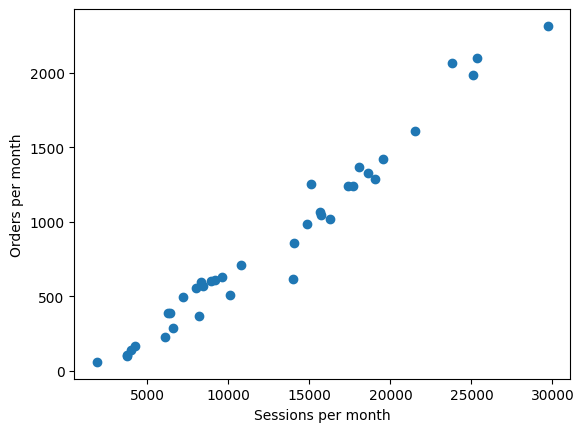

In [ ]:
# Plot the data
plt.plot(X,y,'o')
plt.xlabel('Sessions per month')
plt.ylabel('Orders per month')

In [ ]:
# Create a linear model (OLS Model)
model = make_pipeline(MinMaxScaler(), LinearRegression())

In [ ]:
# R2 claculation
print(model.score(X,y))

0.9678566372161077


Text(0, 0.5, 'Orders per month')

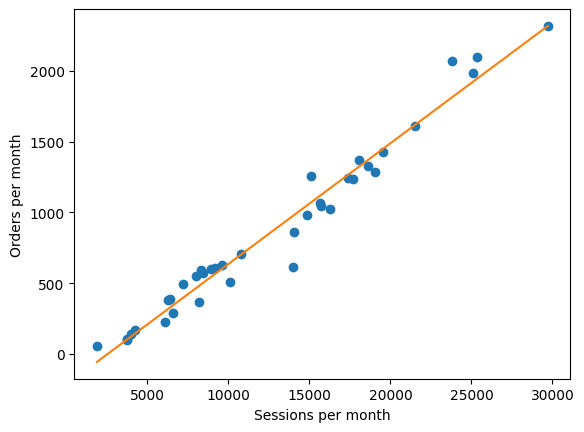

In [ ]:
# Data used for predictions
x_fit = np.linspace(X.min(), X.max(), 500)[:,np.newaxis]
y_fit = model.predict(x_fit)
plt.plot(X,y,'o')
plt.plot(x_fit,y_fit)
plt.xlabel('Sessions per month')
plt.ylabel('Orders per month')

In [ ]:
# How many orders would we expect from a month with 30,000 sessions?
model.predict([[30000]])

array([2339.85073087])